In [2]:
# Import Libraries
import numpy as np
import pandas as pd
import sklearn
import pickle

import matplotlib.pyplot as plt
import cv2

In [3]:
# Load all models
haar = cv2.CascadeClassifier('../models/haarcascade_frontalface_default.xml')
model_svm = pickle.load(open('../models/model_svm.pickle', mode='rb'))
pca_models = pickle.load(open('../models/pca_dict_50.pickle', mode='rb'))

In [4]:
model_pca = pca_models['pca']
mean_face_arr = pca_models['mean_face']

# Create Pipeline

In [33]:
# Step-01: Read Image
img = cv2.imread('../test_images/03.jpg')
# Step-02: Convert into gray scale
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Step-03: Crop the face using haar cascase classifier
faces = haar.detectMultiScale(gray_img, 1.5, 3)
predictions = []
for x,y,w,h in faces:
    faces_roi = gray_img[y:y+h, x:x+w]
    
    # Step-04: Normalization (0-1)
    faces_roi = faces_roi / 255.0
    
    # Step-05: Resize Image (100, 100)
    if faces_roi.shape[1] > 100:
        faces_roi_resize = cv2.resize(faces_roi, (100, 100), cv2.INTER_AREA)
    else:
        faces_roi_resize = cv2.resize(faces_roi, (100, 100), cv2.INTER_CUBIC)
    
    # Step-06: Flattening (1x10000)
    faces_roi_reshape = faces_roi_resize.reshape(1, 10000)
        
    # Step-07: Substract with Mean Face
    faces_roi_mean = faces_roi_reshape - mean_face_arr
    
    # Step-08: Get Eigen Image
    eigen_image = model_pca.transform(faces_roi_mean)
    
    # Step-09: Eigen Image for Visualization
    eig_img = model_pca.inverse_transform(eigen_image)
    
    # Step-10: Pass to Machine Learning Model (SVM) and get predictions
    results = model_svm.predict(eigen_image)
    
    # Step-11: Generate Report
    text = "%s" % results[0]
    if results[0] == 'male':
        color = (255, 255, 0)
    else:
        color = (255, 0, 255)

    cv2.rectangle(img, (x, y), (x+w, y+h), color, 2)
    cv2.putText(img, text, (x, y), cv2.FONT_HERSHEY_PLAIN, 3, (255, 255, 255), 5)
    output = {
        'faces_roi': faces_roi,
        'eigen_image': eig_img,
        'prediction_name': results[0]
    }

    predictions.append(output)

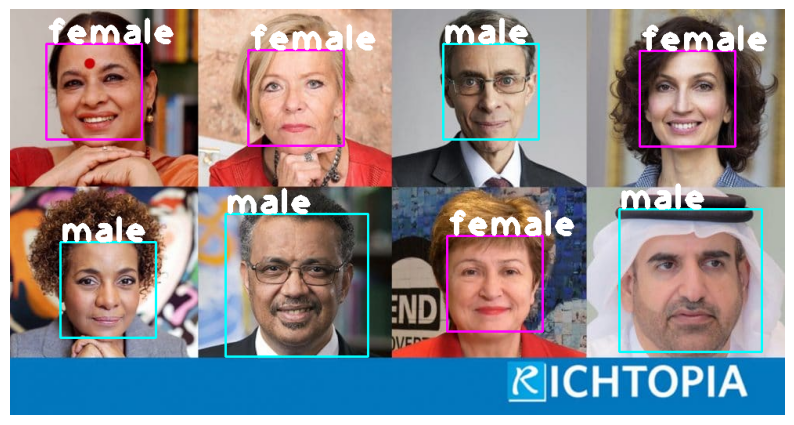

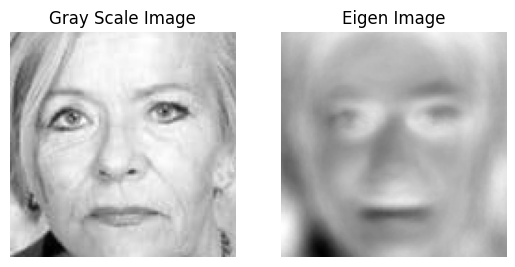

Predicted Gender =  female
----------------------------------------------------------------------------------------------------


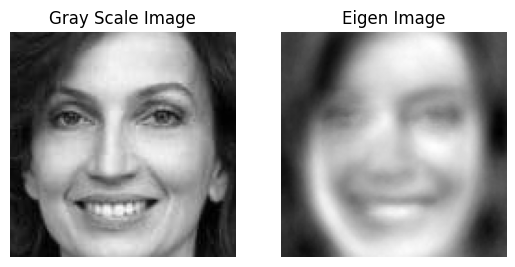

Predicted Gender =  female
----------------------------------------------------------------------------------------------------


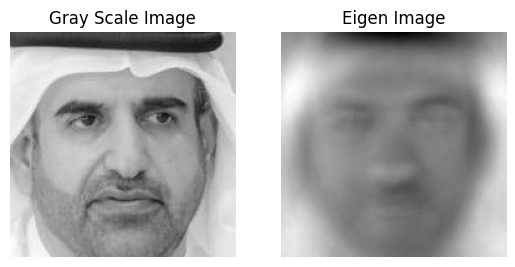

Predicted Gender =  male
----------------------------------------------------------------------------------------------------


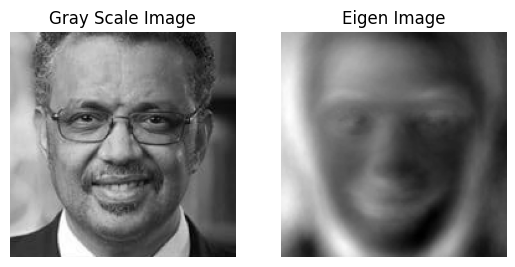

Predicted Gender =  male
----------------------------------------------------------------------------------------------------


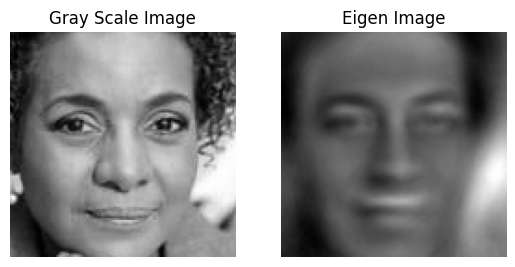

Predicted Gender =  male
----------------------------------------------------------------------------------------------------


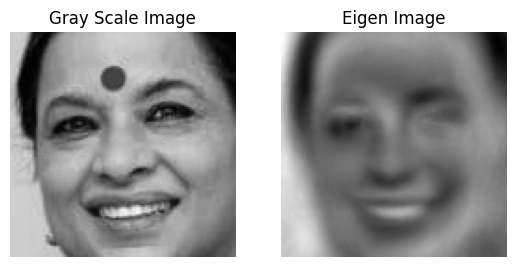

Predicted Gender =  female
----------------------------------------------------------------------------------------------------


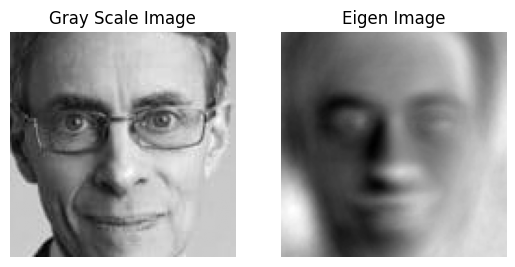

Predicted Gender =  male
----------------------------------------------------------------------------------------------------


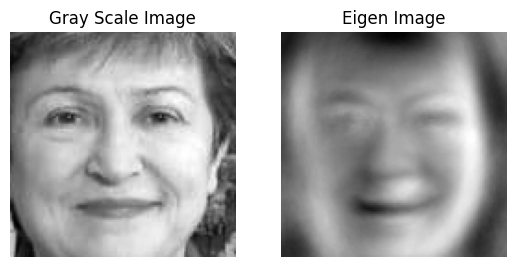

Predicted Gender =  female
----------------------------------------------------------------------------------------------------


In [34]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 10))
plt.imshow(img_rgb)
plt.axis('off')
# plt.savefig("../save_data/images//main_image.jpg", bbox_inches='tight', dpi=300)
plt.show()

## Generating Report
for i in range(len(predictions)):
    obj_gray = predictions[i]['faces_roi']
    obj_eigen = predictions[i]['eigen_image'].reshape(100, 100)
    plt.subplot(1,2,1)
    plt.imshow(obj_gray, cmap='gray')
    plt.title('Gray Scale Image')
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(obj_eigen, cmap='gray')
    plt.title('Eigen Image')
    plt.axis('off')

    filename = f"../save_data/images/result_{i}.jpg"
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    
    plt.show()

    print('Predicted Gender = ', predictions[i]['prediction_name'])
    print('-'*100)